## EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/tanaphan/Downloads/11_7_26.csv")
df.shape

(13544, 13)

In [2]:
df.dtypes

com_num                     object
name                        object
sic_code                     int64
account_type                object
lloyds_customer               bool
recent_psc_kind             object
recent_charge_status        object
recent_charge_created_on    object
accounts_overdue              bool
company_type                object
post_code                   object
town_api                    object
region                      object
dtype: object

In [3]:
df.head()

,com_num,name,sic_code,account_type,lloyds_customer,recent_psc_kind,recent_charge_status,recent_charge_created_on,accounts_overdue,company_type,post_code,town_api,region
0,15073164,NFLECTION ADVISORY LIMITED,70229,total-exemption-full,False,individual-person-with-significant-control,no_charges,no_charges,False,Private Limited Company,EN6 2DA,Hertsmere,East of England
1,13522064,NFOGENIE LTD,58290,micro-entity,False,individual-person-with-significant-control,no_charges,no_charges,False,Private Limited Company,WC2H 9JQ,Camden,London
2,11006939,NNOV8 LIMITED,62090,micro-entity,False,individual-person-with-significant-control,no_charges,no_charges,False,Private Limited Company,TN8 5NF,Sevenoaks,South East
3,SC606050,NSPIRED INVESTMENTS LTD,68209,total-exemption-full,False,individual-person-with-significant-control,outstanding,2021-09-01,False,Private Limited Company,AB11 7SY,Aberdeen City,Scotland
4,11303802,"""1ST RATE"" PSYCHOLOGY SERVICES LTD",85600,micro-entity,False,individual-person-with-significant-control,no_charges,no_charges,False,Private Limited Company,SS3 0GW,Rochford,East of England


In [4]:
df.isnull().sum()

com_num                      0
name                         0
sic_code                     0
account_type                 0
lloyds_customer              0
recent_psc_kind              0
recent_charge_status         0
recent_charge_created_on     0
accounts_overdue             0
company_type                43
post_code                   49
town_api                    53
region                      53
dtype: int64

In [5]:
df["lloyds_customer"].value_counts()

lloyds_customer
False    13308
True       236
Name: count, dtype: int64

In [6]:
df["lloyds_customer"].value_counts(normalize=True) * 100

lloyds_customer
False    98.257531
True      1.742469
Name: proportion, dtype: float64

In [7]:
df.nunique()

com_num                     13544
name                        13544
sic_code                      463
account_type                    5
lloyds_customer                 2
recent_psc_kind                 4
recent_charge_status            4
recent_charge_created_on     1338
accounts_overdue                2
company_type                    3
post_code                    9995
town_api                      357
region                         12
dtype: int64

In [8]:
df["recent_charge_created_on"].value_counts()

recent_charge_created_on
no_charges    11759
2024-12-20        8
2022-07-29        6
2026-05-13        6
2024-03-28        5
              ...  
2025-12-24        1
2019-11-05        1
2023-02-17        1
1986-11-20        1
2021-09-10        1
Name: count, Length: 1338, dtype: int64

In [9]:
df["sic_code"].value_counts()

sic_code
98000    4125
68209    1264
68100     734
68320     588
82990     375
         ... 
9100        1
16100       1
65300       1
9900        1
32401       1
Name: count, Length: 463, dtype: int64

### EDA Summary:

**Identifier Columns**: "com_num", "name"

**Columns to be dropped** : "recent_charge_created_on", "post_code", "town_api"

**Column to be processed**: "lloyds_customer", "accounts_overdue" --> bool to int

**Change sic_code to sections instead**

**After dropping columns --> drop rows with missing values**

*note* 

"post_code" and "town_api" might be too granular --> try using only "region" first

"sic_code" must be 5-digit but the first "0" is removed --> must be fixed


## Data Cleaning

In [10]:
# Drop unused columns
df= df.drop(columns=["recent_charge_created_on", "post_code", "town_api"])

In [11]:
# Drop rows with missing value
df = df.dropna(subset=["company_type", "region"])

In [12]:
# Change int to str + add "0" to all 4-digit codes
df["sic_code"] = df["sic_code"].astype(str).str.zfill(5)

https://resources.companieshouse.gov.uk/sic/

In [13]:
# Create a map/dict for SIC sections according to https://resources.companieshouse.gov.uk/sic/
SIC_SECTIONS = [
    (1, 3, "A: Agriculture"),
    (5, 9, "B: Mining"),
    (10, 33, "C: Manufacturing"),
    (35, 35, "D: Utilities"),
    (36, 39, "E: Water/Waste"),
    (41, 43, "F: Construction"),
    (45, 47, "G: Retail/Wholesale"),
    (49, 53, "H: Transport"),
    (55, 56, "I: Accommodation/Food"),
    (58, 63, "J: Information/Comms"),
    (64, 66, "K: Finance/Insurance"),
    (68, 68, "L: Real Estate"),
    (69, 75, "M: Professional/Scientific"),
    (77, 82, "N: Admin Support"),
    (84, 84, "O: Public Admin"),
    (85, 85, "P: Education"),
    (86, 88, "Q: Health/Social"),
    (90, 93, "R: Arts/Recreation"),
    (94, 96, "S: Other Services"),
    (97, 98, "T: Household Activities"),
    (99, 99, "U: Extraterritorial"),
]

def code_to_section(code):
    div = int(code[:2]) # get only first 2 letter + change it back to int
    for lo, hi, section in SIC_SECTIONS:
        if lo <= div <= hi:
            return section
    return "Unknown"


In [14]:
df["sic_section"] = df["sic_code"].apply(code_to_section)

df = df.drop(columns="sic_code")

df["sic_section"].value_counts()

sic_section
T: Household Activities       4124
L: Real Estate                2649
M: Professional/Scientific     994
F: Construction                855
J: Information/Comms           805
N: Admin Support               777
G: Retail/Wholesale            768
I: Accommodation/Food          462
S: Other Services              436
H: Transport                   273
K: Finance/Insurance           251
Q: Health/Social               245
C: Manufacturing               228
R: Arts/Recreation             228
P: Education                   162
U: Extraterritorial             96
A: Agriculture                  41
B: Mining                       28
E: Water/Waste                  24
D: Utilities                    21
Unknown                         18
O: Public Admin                  6
Name: count, dtype: int64

In [15]:
df["lloyds_customer"] = df["lloyds_customer"].astype(int)
df["accounts_overdue"] = df["accounts_overdue"].astype(int)

In [16]:
df.dtypes

com_num                 object
name                    object
account_type            object
lloyds_customer          int64
recent_psc_kind         object
recent_charge_status    object
accounts_overdue         int64
company_type            object
region                  object
sic_section             object
dtype: object

In [17]:
df.shape

(13491, 10)

In [18]:
df.head()

,com_num,name,account_type,lloyds_customer,recent_psc_kind,recent_charge_status,accounts_overdue,company_type,region,sic_section
0,15073164,NFLECTION ADVISORY LIMITED,total-exemption-full,0,individual-person-with-significant-control,no_charges,0,Private Limited Company,East of England,M: Professional/Scientific
1,13522064,NFOGENIE LTD,micro-entity,0,individual-person-with-significant-control,no_charges,0,Private Limited Company,London,J: Information/Comms
2,11006939,NNOV8 LIMITED,micro-entity,0,individual-person-with-significant-control,no_charges,0,Private Limited Company,South East,J: Information/Comms
3,SC606050,NSPIRED INVESTMENTS LTD,total-exemption-full,0,individual-person-with-significant-control,outstanding,0,Private Limited Company,Scotland,L: Real Estate
4,11303802,"""1ST RATE"" PSYCHOLOGY SERVICES LTD",micro-entity,0,individual-person-with-significant-control,no_charges,0,Private Limited Company,East of England,P: Education


## Model Training

In [19]:
from sklearn.model_selection import train_test_split

RS = 42

feature_cols = ["account_type", "recent_psc_kind", "recent_charge_status",
                 "accounts_overdue", "company_type", "region", "sic_section"]
target_col = "lloyds_customer"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RS, stratify=y
)

In [20]:
print(f"Train: {len(X_train)} rows: {y_train.sum()} Lloyds customers")
print(f"Test: {len(X_test)} rows: {y_test.sum()} Lloyds customers")

Train: 10792 rows: 189 Lloyds customers
Test: 2699 rows: 47 Lloyds customers


### Logistic Regression

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

cat_cols = ["account_type", "recent_psc_kind", "recent_charge_status",
            "company_type", "region", "sic_section"]

preprocess = ColumnTransformer([
    ("cat_encode", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

model_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RS)
pipe_lr = Pipeline([
    ("prep", preprocess),
    ("clf", model_lr)
])

# X_train_encoded = preprocess.fit_transform(X_train)
# model.fit(X_train_encoded, y_train)

In [22]:
pipe_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluate

In [23]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_curve

y_pred_lr = pipe_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.89      0.94      2652
    Lloyds Customer       0.14      1.00      0.25        47

           accuracy                           0.89      2699
          macro avg       0.57      0.95      0.60      2699
       weighted avg       0.99      0.89      0.93      2699



In [24]:
confusion_matrix(y_test, y_pred_lr)

array([[2366,  286],
       [   0,   47]])

In [25]:
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC: {auc_lr}")

ROC-AUC: 0.9594164179583453


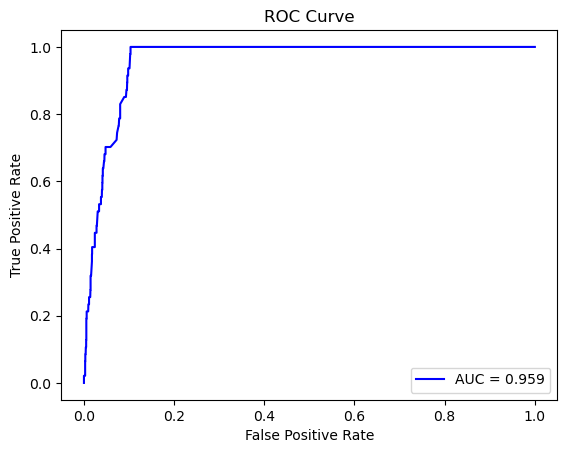

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_lr:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
ap_lr = average_precision_score(y_test, y_proba_lr)
print(f"Average Precision: {ap_lr}")

Average Precision: 0.24559696223524013


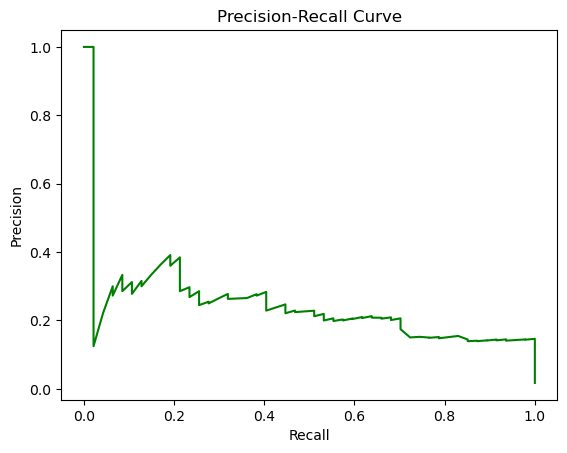

In [28]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)
plt.plot(rec, prec, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=RS)

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("clf_rf", model_rf)
])

pipe_rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf_rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred_rf = pipe_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       1.00      0.89      0.94      2652
    Lloyds Customer       0.14      1.00      0.25        47

           accuracy                           0.89      2699
          macro avg       0.57      0.95      0.60      2699
       weighted avg       0.99      0.89      0.93      2699



In [31]:
confusion_matrix(y_test, y_pred_rf)

array([[2366,  286],
       [   0,   47]])

TN  FP

FN  TP

In [32]:
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC: {auc_rf}")

ROC-AUC: 0.955364879175893


In [33]:
ap_rf = average_precision_score(y_test, y_proba_rf)
print(f"Average Precision: {ap_rf}")

Average Precision: 0.23618594489586686


### XGBoost